In [1]:
!pip install torchvision

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import torchvision

In [4]:
image = cv2.imread(r"C:\Users\Victor\Documents\nexvisual\dog.jpg")

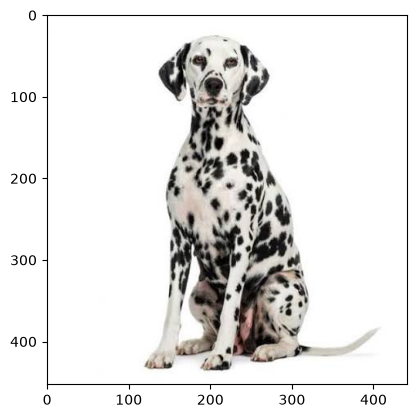

In [5]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

In [11]:
# Definindos os pesos a serem utilizados
weights = torchvision.models.VGG16_Weights.DEFAULT

imagenet_labels = weights.meta["categories"]

# Carregar o modelo
vgg_16_model = torchvision.models.vgg16(weights)

# Criando o pipeline de transformações de pré-processamento dos dados.
preprocess = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize(256),
    torchvision.transforms.CenterCrop(224),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

C:\Users\Victor\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(


In [12]:
# Colocar o modelo em modo de avaliação
vgg_16_model.eval()

# Pré processamento da imagem
image_tensor = preprocess(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
input_batch = image_tensor.unsqueeze(0)

print(image_tensor.shape, input_batch.shape)

torch.Size([3, 224, 224]) torch.Size([1, 3, 224, 224])


In [10]:
# Escolhendo o dispositivo a ser utilizado GPU se disponível
if torch.cuda.is_available():
    input_batch = input_batch.to('cuda')
    vgg_16_model.to('cuda')

# Rodando a inferência
with torch.no_grad():
    output = vgg_16_model(input_batch)
    
# Calculando as probabilidades das classes
probabilities = torch.nn.functional.softmax(output[0], dim=0)    

Classe predita para imagem: dalmatian


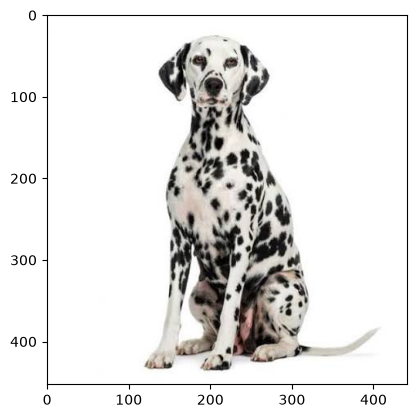

In [13]:
# Validando a classe prevista
print(f"Classe predita para imagem: {imagenet_labels[torch.argmax(probabilities)]}")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Weimaraner'),
  Text(1, 0, 'muzzle'),
  Text(2, 0, 'Walker hound'),
  Text(3, 0, 'jaguar'),
  Text(4, 0, 'Labrador retriever'),
  Text(5, 0, 'Rhodesian ridgeback'),
  Text(6, 0, 'bluetick'),
  Text(7, 0, 'German short-haired pointer'),
  Text(8, 0, 'Great Dane'),
  Text(9, 0, 'dalmatian')])

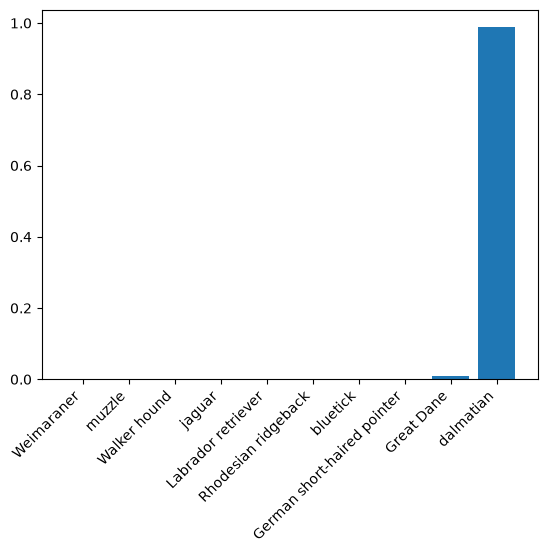

In [14]:
# Criando conjunto de labels e probabilidades, e ordenar
set_labels_probs = list(zip(imagenet_labels, list(probabilities.cpu().numpy())))
set_labels_probs = sorted(set_labels_probs, key=lambda x: x[1])

# Pega as N classes mais prováveis
num = 10
most_probable_classes = set_labels_probs[-num:]

# Criar as listas para o plot
labels, probs = zip(*most_probable_classes)

# Observar as probabilidades
plt.bar(labels, probs)
plt.xticks(rotation=45, ha='right') # Rotacionar as labels em 45 graus e alinhar a direito